In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pynamicalsys import PlotStyler
from pynamicalsys import HamiltonianSystem as HS

In [2]:
time_step = 0.01

In [3]:
num_ic = 200
dof = 2
q = np.zeros((num_ic, dof))
p = np.zeros((num_ic, dof))
E = 1 / 8  # Total energy of the system
x = 0  # Define the initial condition
y_range = (-0.5, 0.5)
py_range = (-0.5, 0.5)

np.random.seed(13)
for i in range(num_ic):
    while True:
        py = np.random.uniform(*py_range)
        y = np.random.uniform(*y_range)
        px = 2 * (E - x**2 * y + y**3 / 3) - x**2 - y**2 - py**2
        if px > 0:
            q[i] = [x, y]
            p[i] = [np.sqrt(px), py]
            break


num_intersections = 5000

In [4]:
hs = HS(model="henon heiles")

In [5]:
PS = hs.poincare_section(q, p, num_intersections)

In [7]:
PS.shape

(200, 5000, 5)

Text(0, 0.5, '$p_y$')

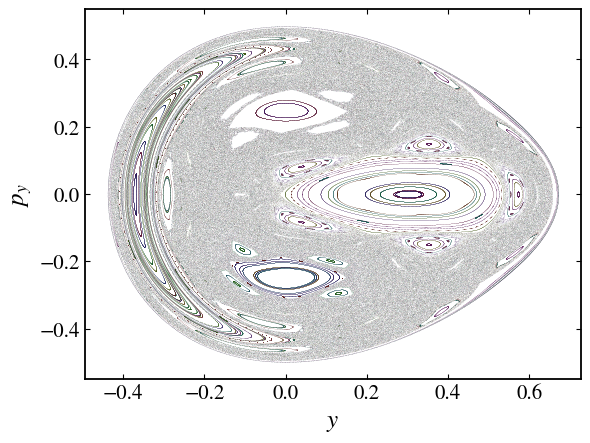

In [8]:
ps = PlotStyler(fontsize=18, markersize=0.1, markeredgewidth=0)
ps.apply_style()
colors = sns.color_palette("hls", num_ic)

for i in range(num_ic):
    plt.plot(PS[i, :, 2], PS[i, :, 4], "o", c=colors[i])
plt.xlabel("$y$")
plt.ylabel("$p_y$")